In [2]:
import json
from pathlib import Path

embeddings_path = Path("../data/embeddings/bert-base")
progress_path = embeddings_path / "progress.json"


with open(progress_path, "r") as f:
        progress = json.load(f)

In [3]:
import math
import pandas as pd
import gc 
from sklearn.cluster import DBSCAN
import numpy
import collections


def get_clusters(sample_size, epsilon, minPts):
    
    ########### SAMPLE ########################
    nr_of_files = math.ceil(sample_size/4000)
    print(nr_of_files)

    # load list of all files 
    chunk_files = sorted((embeddings_path / "chunks").glob("chunk_*.parquet"))
    print(len(chunk_files))

    bert_embeddings = pd.read_parquet(
        chunk_files[:nr_of_files],
        columns=["id", "layer_last"],
    )

    if bert_embeddings.shape[0]> sample_size:
        bert_embeddings = bert_embeddings[:sample_size]

    bert_embeddings.shape

    ########### GARBAGE COLLECTION ############
    gc.collect()

    ########### CLUSTERING ###########
    X = numpy.stack(bert_embeddings.layer_last.to_numpy())  # shape (n_samples, 768)

    clusterer = DBSCAN(min_samples=minPts, eps=epsilon, metric='cosine')

    labels = clusterer.fit_predict(X)
    counter = collections.Counter(labels)

    return counter


In [16]:
gc.collect()


0

In [4]:
get_clusters(500, 0.2, 380)

1
124


Counter({np.int64(-1): 500})

In [5]:
import time
from datetime import datetime

cluster_info = []
epsilon = 0.2
minPts = 380

for size in [500, 5000, 10000, 20000, 50000]:
    current_cluster = {}
    current_cluster["sample_size"] = size
    # set up time logging
    current_cluster["start_time"] = datetime.now().isoformat()
    start_ts = time.monotonic()  # for computing elapsed duration cheaply

    cluster_dist = get_clusters(size, epsilon=epsilon, minPts=minPts)

    current_cluster["end_time"] = datetime.now().isoformat()
    current_cluster["elapsed_seconds"] = round(time.monotonic() - start_ts, 1)
    current_cluster["epsilon"] = epsilon
    current_cluster["minPts"] = minPts
    current_cluster["cluster_dist"] = cluster_dist
    cluster_info.append(current_cluster)



1
124
2
124
3
124
5
124
13
124


In [6]:
cluster_info

[{'sample_size': 500,
  'start_time': '2026-08-19T19:16:05.559686',
  'end_time': '2026-08-19T19:16:05.768127',
  'elapsed_seconds': 0.2,
  'epsilon': 0.2,
  'minPts': 380,
  'cluster_dist': Counter({np.int64(-1): 500})},
 {'sample_size': 5000,
  'start_time': '2026-08-19T19:16:05.768178',
  'end_time': '2026-08-19T19:16:06.736649',
  'elapsed_seconds': 1.0,
  'epsilon': 0.2,
  'minPts': 380,
  'cluster_dist': Counter({np.int64(-1): 3889, np.int64(0): 1111})},
 {'sample_size': 10000,
  'start_time': '2026-08-19T19:16:06.736673',
  'end_time': '2026-08-19T19:16:09.788924',
  'elapsed_seconds': 3.1,
  'epsilon': 0.2,
  'minPts': 380,
  'cluster_dist': Counter({np.int64(0): 5763, np.int64(-1): 4237})},
 {'sample_size': 20000,
  'start_time': '2026-08-19T19:16:09.788946',
  'end_time': '2026-08-19T19:16:21.119558',
  'elapsed_seconds': 11.3,
  'epsilon': 0.2,
  'minPts': 380,
  'cluster_dist': Counter({np.int64(0): 14578,
           np.int64(-1): 5041,
           np.int64(1): 381})},
 {'sa

In [7]:
with open("cluster_speed_myPC.jsonl", "w") as f:
    for item in cluster_info:
        item = item.copy()
        item["cluster_dist"] = {
            int(k): int(v)
            for k, v in item["cluster_dist"].items()
        }

        f.write(json.dumps(item) + "\n")

4000 - instant
40.000 - 48.9 seconds
80.000 - 3min 16.8s
160.000 - 15min 7.9s

## visualize the difference

In [1]:
import pandas as pd

df = pd.read_json("cluster_speed_kaggle.jsonl", lines=True)
df["source"] = "kaggle"

In [11]:
df_here = pd.DataFrame(cluster_info)
df_here["source"] = "myPC"

In [12]:
# combine both
df = pd.concat([df, df_here], ignore_index=True)

In [13]:
df

,sample_size,start_time,end_time,elapsed_seconds,epsilon,minPts,cluster_dist,source
0,500,2026-08-19 17:02:09.393748,2026-08-19 17:02:10.294946,0.9,0.2,380,{'-1': 500},kaggle
1,5000,2026-08-19 17:02:10.294981,2026-08-19 17:02:11.872206,1.6,0.2,380,"{'-1': 3921, '0': 1079}",kaggle
2,10000,2026-08-19 17:02:11.872236,2026-08-19 17:02:15.144388,3.3,0.2,380,"{'-1': 4181, '0': 5819}",kaggle
3,20000,2026-08-19 17:02:15.144420,2026-08-19 17:02:30.349287,15.2,0.2,380,"{'-1': 5251, '0': 14749}",kaggle
4,50000,2026-08-19 17:02:30.349321,2026-08-19 17:04:04.280368,93.9,0.2,380,"{'0': 43729, '-1': 6271}",kaggle
5,500,2026-08-19T19:16:05.559686,2026-08-19T19:16:05.768127,0.2,0.2,380,{-1: 500},myPC
6,5000,2026-08-19T19:16:05.768178,2026-08-19T19:16:06.736649,1.0,0.2,380,"{-1: 3889, 0: 1111}",myPC
7,10000,2026-08-19T19:16:06.736673,2026-08-19T19:16:09.788924,3.1,0.2,380,"{-1: 4237, 0: 5763}",myPC
8,20000,2026-08-19T19:16:09.788946,2026-08-19T19:16:21.119558,11.3,0.2,380,"{-1: 5041, 0: 14578, 1: 381}",myPC
9,50000,2026-08-19T19:16:21.119585,2026-08-19T19:17:20.505744,59.4,0.2,380,"{0: 43565, -1: 6435}",myPC


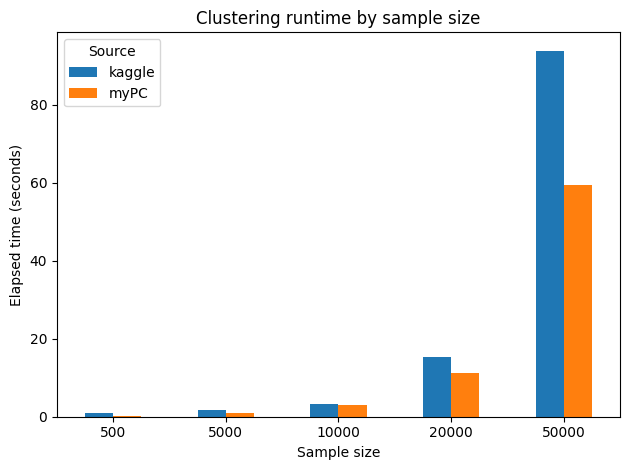

In [14]:
import matplotlib.pyplot as plt

df.pivot(
    index="sample_size",
    columns="source",
    values="elapsed_seconds"
).plot(kind="bar")

plt.xlabel("Sample size")
plt.ylabel("Elapsed time (seconds)")
plt.title("Clustering runtime by sample size")
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.tight_layout()
plt.show()

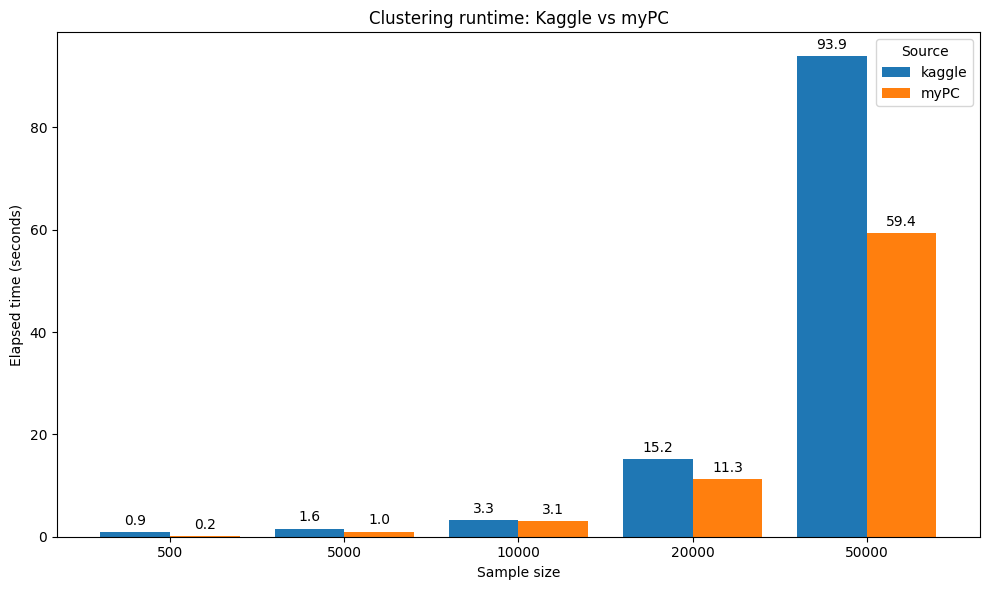

In [15]:
import matplotlib.pyplot as plt

plot_df = (
    df.pivot(index="sample_size", columns="source", values="elapsed_seconds")
      .sort_index()
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

# Add exact values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

ax.set_xlabel("Sample size")
ax.set_ylabel("Elapsed time (seconds)")
ax.set_title("Clustering runtime: Kaggle vs myPC")
ax.set_xticklabels(plot_df.index, rotation=0)
ax.legend(title="Source")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

In [2]:
# only the kaggle data with doubling of the sample size
df_speed_doubling = pd.read_json("cluster_speed_kaggle_larger.jsonl", lines=True)

df_speed_doubling

,sample_size,start_time,end_time,elapsed_seconds,epsilon,minPts,cluster_dist
0,500,2026-08-19 17:50:27.843278,2026-08-19 17:50:28.487844,0.6,0.2,380,{'-1': 500}
1,5000,2026-08-19 17:50:28.487879,2026-08-19 17:50:29.711013,1.2,0.2,380,"{'-1': 3889, '0': 1111}"
2,10000,2026-08-19 17:50:29.711044,2026-08-19 17:50:32.744828,3.0,0.2,380,"{'-1': 4237, '0': 5763}"
3,20000,2026-08-19 17:50:32.744862,2026-08-19 17:50:47.911815,15.2,0.2,380,"{'-1': 5041, '0': 14578, '1': 381}"
4,40000,2026-08-19 17:50:47.911848,2026-08-19 17:51:47.243335,59.3,0.2,380,"{'0': 34011, '-1': 5989}"
5,60000,2026-08-19 17:51:47.243372,2026-08-19 17:54:02.645091,135.4,0.2,380,"{'0': 53649, '-1': 6351}"
6,80000,2026-08-19 17:54:02.645132,2026-08-19 17:58:08.372792,245.7,0.2,380,"{'0': 73518, '-1': 6482}"
7,100000,2026-08-19 17:58:08.372832,2026-08-19 18:04:34.788741,386.4,0.2,380,"{'0': 93319, '-1': 6681}"


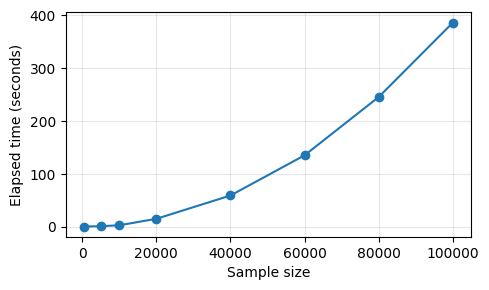

In [8]:
import matplotlib.pyplot as plt

df = df_speed_doubling.sort_values("sample_size")

plt.figure(figsize=(5, 3))

plt.plot(
    df["sample_size"],
    df["elapsed_seconds"],
    marker="o"
)

plt.xlabel("Sample size")
plt.ylabel("Elapsed time (seconds)")
#plt.title("Kaggle runtime")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

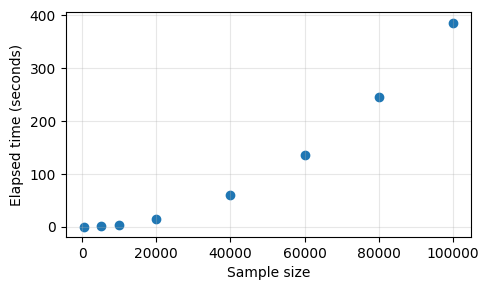

In [22]:
import matplotlib.pyplot as plt

df = df_speed_doubling.sort_values("sample_size")

plt.figure(figsize=(5, 3))

plt.scatter(
    df["sample_size"],
    df["elapsed_seconds"]
)

plt.xlabel("Sample size")
plt.ylabel("Elapsed time (seconds)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X = df[["sample_size"]]
y = df["elapsed_seconds"]

model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(X, y)

# Predict
predicted = model.predict([[50_000]])[0]
print(f"Estimated time: {predicted:.2f} seconds")

Estimated time: 93.75 seconds


/home/liane/Documents/SEDS/Master thesis/ma_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [10]:
df["predicted_seconds"] = model.predict(df[["sample_size"]])

/home/liane/Documents/SEDS/Master thesis/ma_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


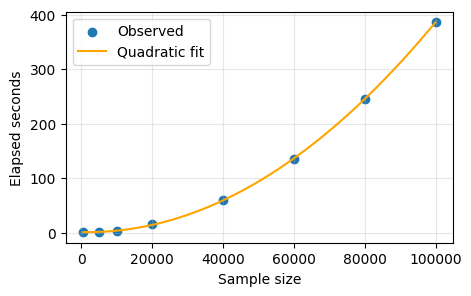

In [26]:
import matplotlib.pyplot as plt
import numpy as np

x_plot = np.linspace(df["sample_size"].min(), 100_000, 200)
y_plot = model.predict(x_plot.reshape(-1, 1))

plt.figure(figsize=(5, 3))


plt.scatter(df["sample_size"], df["elapsed_seconds"], label="Observed")
plt.plot(x_plot, y_plot, label="Quadratic fit", color = "orange")
plt.xlabel("Sample size")
plt.ylabel("Elapsed seconds")
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()

In [13]:
poly = model.named_steps["polynomialfeatures"]
reg = model.named_steps["linearregression"]

print("Features:", poly.get_feature_names_out(["sample_size"]))
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

Features: ['1' 'sample_size' 'sample_size^2']
Coefficients: [ 0.00000000e+00 -1.40327782e-04  3.99493370e-08]
Intercept: 0.8980433855906824


In [21]:
# predict for sample_size = 500_000
seconds_500k = model.predict([[500_000]])[0]
print(seconds_500k)

hours_500k = seconds_500k/3600

print(hours_500k)

9918.068397896132
2.7550189994155923


/home/liane/Documents/SEDS/Master thesis/ma_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
